In [3]:
from typing import Sequence, cast
from utils.logging import setup_root_logger
from utils.path_utils import get_project_root
from persistence.context import ModelContext
from persistence.schemas.clinicals import StudyEstimate
from analysis.psa.parameters import Parameter
from analysis.distributions import (
    Bayesian,
    DirichletMixture,
    Distribution,
    GammaFromMeanSD,
)
import matplotlib.pyplot as plt
import numpy as np


%matplotlib inline

logger = setup_root_logger()
root = get_project_root()



# Loaded data
context = ModelContext.load()

# Unpack
seed = context.simulation.environment.seed
mode: str = context.simulation.environment.mode
rng = np.random.default_rng(seed)
sample_size = (
    context.simulation.psa.production
    if mode == "production"
    else context.simulation.psa.development
)
# ----------------------------------------------
# Annual bleeding rate meta-analysis studies
# ----------------------------------------------
meta_components = {
    "on_demand": {
        "bayesian": [
            StudyEstimate(mean=s.mean, sd=s.sd, size=s.size)
            for s in context.clinical.evidence.abr.on_demand
        ],
        "dirichlet": cast(
            Sequence[Distribution],
            [
                GammaFromMeanSD(mean=s.mean, sd=s.sd)
                for s in context.clinical.evidence.abr.on_demand
            ],
        ),
    },
    "prophylaxis": {
        "bayesian": [
            StudyEstimate(mean=s.mean, sd=s.sd, size=s.size)
            for s in context.clinical.evidence.abr.prophylaxis
        ],
        "dirichlet": cast(
            Sequence[Distribution],
            [
                GammaFromMeanSD(mean=s.mean, sd=s.sd)
                for s in context.clinical.evidence.abr.prophylaxis
            ],
        ),
    },
}


on_demand_abr_param = {
    "bayesian": Parameter(
        distribution=Bayesian(studies=meta_components["on_demand"]["bayesian"])
    ),
    "dirichlet": Parameter(
        distribution=DirichletMixture(
            components=meta_components["on_demand"]["dirichlet"]
        )
    ),
}
prophylaxis_abr_param = {
    "bayesian": Parameter(
        distribution=Bayesian(studies=meta_components["prophylaxis"]["bayesian"])
    ),
    "dirichlet": Parameter(
        distribution=DirichletMixture(
            components=meta_components["prophylaxis"]["dirichlet"]
        )
    ),
}

samples = {
    "on_demand": {
        "bayesian": on_demand_abr_param["bayesian"].sample(sample_size, rng),
        "dirichlet": on_demand_abr_param["dirichlet"].sample(sample_size, rng),
    },
    "prophylaxis": {
        "bayesian": prophylaxis_abr_param["bayesian"].sample(sample_size, rng),
        "dirichlet": prophylaxis_abr_param["dirichlet"].sample(sample_size, rng),
    },
}

Initializing NUTS using jitter+adapt_diag...


[11:09:35] INFO     Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


[11:09:36] INFO     Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau, z]


...

[11:09:51] INFO     Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau, z]


[11:09:51] INFO     NUTS: [mu, tau, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


[11:10:05] INFO     Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


In [4]:
import pickle

path = root / "cache/samples.pkl"
with open(path, "wb") as f:
    pickle.dump(samples, f)

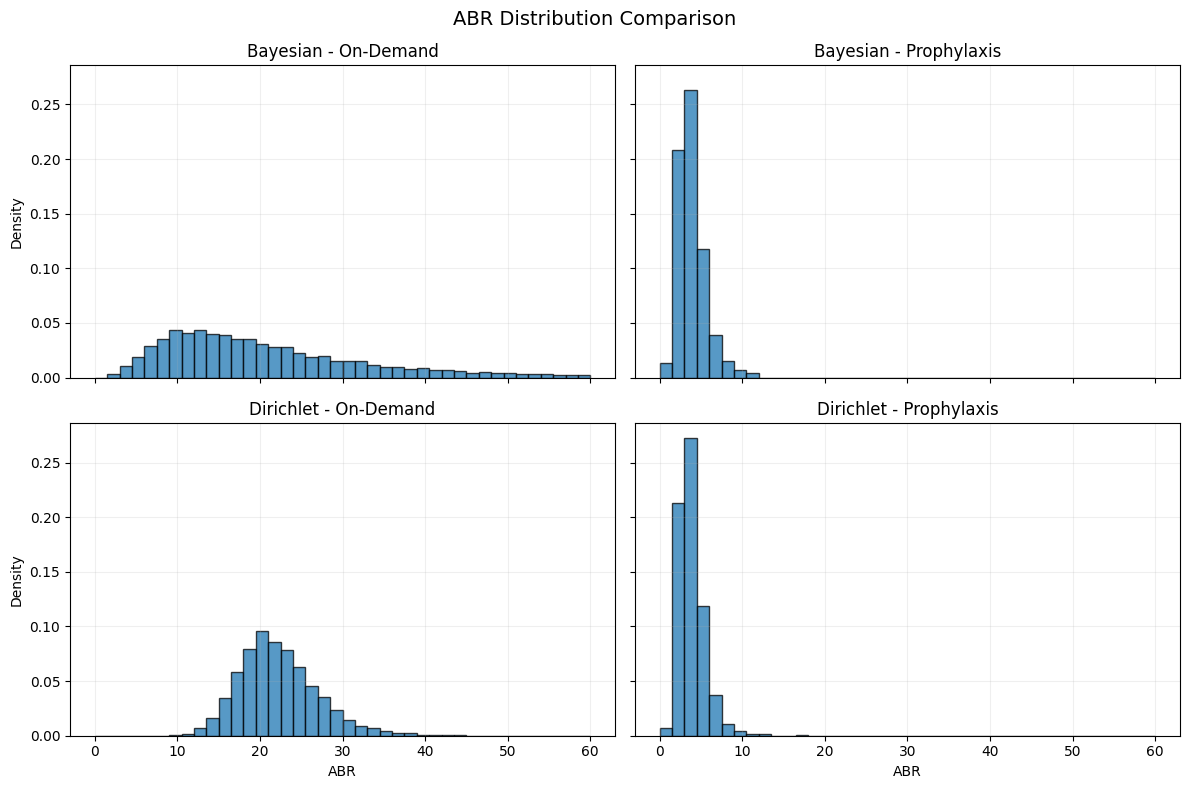

In [5]:
# -----------------------------------
# ** Plot (2x2 layout) **
# -----------------------------------
# Helper
def plot_hist(ax, data, title):
    ax.hist(
        data,
        bins=40,
        range=(0, 60),  # tighter range improves visibility
        density=True,
        alpha=0.75,
        edgecolor="black",
    )
    ax.set_title(title)
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle("ABR Distribution Comparison", fontsize=14)


# --- Bayesian ---
plot_hist(
    axes[0, 0],
    samples["on_demand"]["bayesian"],
    "Bayesian - On-Demand",
)
plot_hist(
    axes[0, 1],
    samples["prophylaxis"]["bayesian"],
    "Bayesian - Prophylaxis",
)

# --- Dirichlet ---
plot_hist(
    axes[1, 0],
    samples["on_demand"]["dirichlet"],
    "Dirichlet - On-Demand",
)
plot_hist(
    axes[1, 1],
    samples["prophylaxis"]["dirichlet"],
    "Dirichlet - Prophylaxis",
)


# Axis labels (clean separation)
axes[1, 0].set_xlabel("ABR")
axes[1, 1].set_xlabel("ABR")
axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [6]:
# -----------------------------------------
# Logging ABR Values
# -----------------------------------------


def summarize(x: np.ndarray) -> dict:
    return {
        "n": len(x),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "median": float(np.median(x)),
        "p25": float(np.percentile(x, 25)),
        "p75": float(np.percentile(x, 75)),
        "p2_5": float(np.percentile(x, 2.5)),
        "p97_5": float(np.percentile(x, 97.5)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
    }


abr_stats = {
    "Bayesian - On-Demand": summarize(samples["on_demand"]["bayesian"]),
    "Bayesian - Prophylaxis": summarize(samples["prophylaxis"]["bayesian"]),
    "Dirichlet - On-Demand": summarize(samples["on_demand"]["dirichlet"]),
    "Dirichlet - Prophylaxis": summarize(samples["prophylaxis"]["dirichlet"]),
}

for name, s in abr_stats.items():
    logger.info(f"\n=== {name} ===")
    logger.info(f"N: {s['n']}")
    logger.info(f"Mean: {s['mean']:.2f}")
    logger.info(f"SD: {s['std']:.2f}")
    logger.info(f"Median: {s['median']:.2f}")
    logger.info(f"IQR: [{s['p25']:.2f}, {s['p75']:.2f}]")
    logger.info(f"95% CrI: [{s['p2_5']:.2f}, {s['p97_5']:.2f}]")
    logger.info(f"Range: [{s['min']:.2f}, {s['max']:.2f}]")

[11:10:21] INFO     
=== Bayesian - On-Demand ===
[11:10:21] INFO     N: 10000
[11:10:21] INFO     Mean: 22.81
[11:10:21] INFO     SD: 16.47
[11:10:21] INFO     Median: 18.37
[11:10:21] INFO     IQR: [11.68, 28.53]
[11:10:21] INFO     95% CrI: [4.89, 68.32]
[11:10:21] INFO     Range: [1.27, 104.45]
[11:10:21] INFO     
=== Bayesian - Prophylaxis ===
[11:10:21] INFO     N: 10000
[11:10:21] INFO     Mean: 3.86
[11:10:21] INFO     SD: 1.64
[11:10:21] INFO     Median: 3.56
[11:10:21] INFO     IQR: [2.73, 4.63]
[11:10:21] INFO     95% CrI: [1.57, 8.20]
[11:10:21] INFO     Range: [0.50, 10.73]
[11:10:21] INFO     
=== Dirichlet - On-Demand ===
[11:10:21] INFO     N: 10000
[11:10:21] INFO     Mean: 22.26
[11:10:21] INFO     SD: 4.79
[11:10:21] INFO     Median: 21.67
[11:10:21] INFO     IQR: [18.96, 24.98]
[11:10:21] INFO     95% CrI: [14.48, 33.52]
[11:10:21] INFO     Range: [9.09, 51.78]
[11:10:21] INFO     
=== Dirichlet - Prophylaxis ===
[11:10:21] INFO     N: 10000
[11:10:21] INFO     Mea